<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões tangenciais em vigas

### Problema 3

Considere a viga construída com um perfil laminado HEB260 na extremidade do qual é soldada a barra ED como indicado na figura. No ponto E estão aplicadas as forças $F_X =$ 30 kN, $F_Y =$ 13 kN e $F_Z =$ 20 kN, respetivamente paralelas aos eixos $x$, $y$ e $z$. Despreze as dimensões transversais da barra ED
e determine:

**a)** A distribuição das tensões normais na secção que contém o ponto B e que dista 320 mm da extremidade, com a posição do eixo neutro e os valores da tensão normal máxima e mínima.

**b)** A distribuição de tensões tangenciais na alma e no banzo da viga para a secção que contém o ponto B e calcule a tensão tangencial máxima nessa secção.

**c)** O tensor das tensões no ponto B localizado na secção ABC para o sistema de eixos indicado.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P3/MSII_Au06_P3.png"
width="1000">

### Resolução

#### **a)** Sabendo que $R=$ 10 kN e $P=$ 1 kN, determine qual o valor máximo da força $Q$ para que a tensão normal na secção DEF não ultrapasse $\sigma_\mathrm{adm}$ = 150 MPa.

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa

class varin: pass

d = varin()
d.z_1 = 200.*1e-3 # unit: m
d.z_2 = 60.*1e-3
d.zB = 65.*1e-3
d.x = 320.*1e-3
d.Fx = 30.*1e3 # unit: N
d.Fy = 13.*1e3 # unit: N
d.Fz = 20.*1e3 # unit: N

HEB260 = varin()
HEB260.A = 11800*1e-6 # unit: m2
HEB260.Iz = 149.e6*1e-12 # unit: m⁴
HEB260.Iy = 51.3e6*1e-12 # unit: m⁴
HEB260.tb = 17.5*1e-3 # unit: mm
HEB260.ta = 10.*1e-3 # unit: mm
HEB260.b = 260.*1e-3 # unit: mm
HEB260.d = 260.*1e-3 # unit: mm

####  Sistema de força-binário equivalente ($N,V_z,V_z,M_x,M_y,M_z$)

- Esforço axial, $N$

\begin{equation*}
x:~\rightarrow(+)  ~ \Rightarrow ~
N = F_x
\end{equation*}

In [2]:
N = d.Fx
print(f'N = {N:.1f} [N]')

N = 30000.0 [N]


- Esforços tranversos, $V_y$

\begin{equation*}
y:~\uparrow(+) ~ \Rightarrow ~
V_y = F_y 
\end{equation*}

In [3]:
Vy = d.Fy
print(f'Vy = {Vy:.1f} [N]')

Vy = 13000.0 [N]


- Esforços tranversos, $V_z$

\begin{equation*}
z:~\swarrow (+) ~ \Rightarrow ~
V_z = - F_z 
\quad\vee\quad
V_z = F_z \nearrow
\end{equation*}

In [4]:
Vz = - d.Fz
print(f'Vz = {Vz:.1f} \u2261 {np.abs(Vz):.1f} \u2197 [N]')

Vz = -20000.0 ≡ 20000.0 ↗ [N]


- Momento torsor em torno do eixo $x$, $M_x(T)$

\begin{equation*}
x-\mathrm{axis}:~
\circlearrowleft (+) ~ \Rightarrow ~
M_x = F_z \cdot d/2 - F_y z_1
\end{equation*}

In [5]:
Mx = - d.Fz*HEB260.d/2 + d.Fy*d.z_1
print(f'Mx = {Mx:.1f} [N.mm]')

Mx = 0.0 [N.mm]


- Momento flexão em torno do eixo $y$, $M_y(T)$

\begin{equation*}
y-\mathrm{axis}:~
\circlearrowleft (+) ~ \Rightarrow ~
M_y = F_z \cdot x_1 + F_x \cdot z_1
\quad(M_y \circlearrowleft)
\end{equation*}

In [6]:
My = d.Fz*d.x + d.Fx*d.z_1
print(f'My = {d.Fz}({d.x}) + {d.Fx}({d.z_1}) = {My:.1f} [N.mm]')

My = 20000.0(0.32) + 30000.0(0.2) = 12400.0 [N.mm]


- Momento flexão em torno do eixo $z$, $M_z(T)$

\begin{equation*}
z-\mathrm{axis}:~
\circlearrowleft (+) ~ \Rightarrow ~
M_z = F_x \cdot d/2 + F_y \cdot x_1 
\quad(M_z \circlearrowleft) 
\end{equation*}

In [7]:
Mz = d.Fx*HEB260.d/2 + d.Fy*d.x 
print(f'Mz = {d.Fx}({HEB260.d/2}) + {d.Fy}({d.x}) = {Mz:.1f} [N.m]')

Mz = 30000.0(0.13) + 13000.0(0.32) = 8060.0 [N.m]


##### Tensão normal gerada pelos esforços $N, M_z, M_y$

Pelo princípio de sobreposição, a tensão normal ao longo do eixo da viga $x$ pelo carregamento combinado é dado por:

\begin{equation*}
\sigma_{xx} = \frac{N}{A} - \frac{M_z}{I_z}y + \frac{M_y}{I_y} z
\end{equation*}

In [8]:

def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr.atoms(sy.Number)})

A = HEB260.A
Iz = HEB260.Iz
Iy = HEB260.Iy

y, z, sigx = sy.symbols('y z sigx')

Eq = sigx - N/A + Mz/Iz*y - My/Iy*z
sigxx = solve(Eq,sigx)[0]
print(f'sigxx(y,z)  = {printsymSF(sigxx*1e-6)} [MPa]')

sigxx(y,z)  = -54.094*y + 241.715*z + 2.542 [MPa]


y = 4.46843604738341*z + 0.0469992009084409 (recta geométrica do eixo neutro) [m]
z = 0.223791946308725*y - 0.0105180426462548 (recta geométrica do eixo neutro) [m]


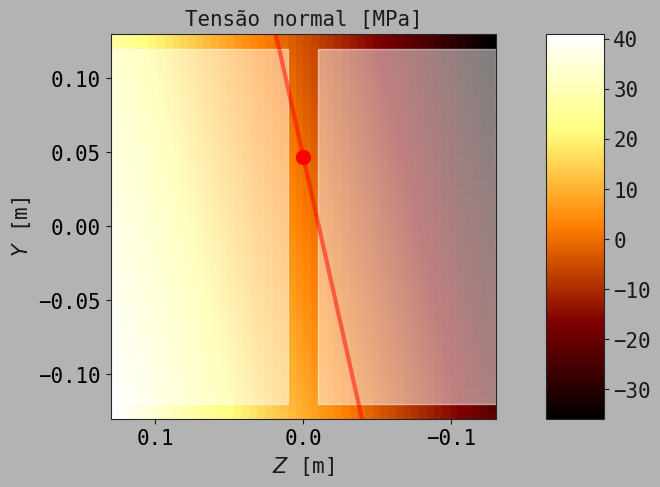

In [9]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle

zsiz = np.linspace(HEB260.b/2,-HEB260.b/2)
ysiz = np.linspace(HEB260.d/2,-HEB260.d/2)
Z, Y = np.meshgrid(zsiz, ysiz)

def tensnormal(y2,z2):
    return sigxx.subs({(y,y2),(z,z2)}) #- eval_NAB/A - eval_MzAB/Iz*y + eval_MyAB/Iy*z

SxxMap = np.zeros(np.shape(Z))
for i in range(0,len(ysiz)):
    for j in range(0,len(zsiz)):
        SxxMap[i,j] = tensnormal(ysiz[i],zsiz[j])

yzfun = solve(sigxx,y)[0]
print(f'y = {yzfun} (recta geométrica do eixo neutro) [m]')
print(f'z = {solve(sigxx,z)[0]} (recta geométrica do eixo neutro) [m]')

zplo = zsiz
yplo = np.zeros(len(zplo))
for i in range(0,len(zplo)):
    yplo[i] = yzfun.subs(z,zplo[i])

fzp = 15
# Visualizacao u1(X1,X2,X3,t1)
fig = plt.figure(figsize=(10, 5))
ax  = plt.gca()
ttl = plt.title('Tensão normal [MPa]',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.ylabel(r'$Y$ [m]',fontsize=fzp)
plt.xlabel(r'$Z$ [m]',fontsize=fzp)
im = ax.imshow(SxxMap*1e-6, extent=[HEB260.b/2, -HEB260.b/2, -HEB260.d/2,HEB260.d/2], cmap="afmhot")
ax.add_patch(Rectangle((-HEB260.b/2, -HEB260.d/2+HEB260.ta), HEB260.b/2-HEB260.ta, HEB260.d-2*HEB260.ta,color="white",alpha=0.5))
ax.add_patch(Rectangle((HEB260.ta, -HEB260.d/2+HEB260.ta), HEB260.b/2-HEB260.ta, HEB260.d-2*HEB260.ta,color="white",alpha=0.5))
plt.plot(zplo,yplo,'r-',linewidth=3,alpha=0.5)
ax.plot(0,yzfun.subs(z,0),'or',markersize=10)
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
plt.xlim(HEB260.b/2,-HEB260.b/2)
plt.ylim(-HEB260.d/2,HEB260.d/2)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="15%", pad=0.5)
cbar = plt.colorbar(im, cax=cax, orientation = "vertical")
cbar.ax.tick_params(labelsize=fzp)
plt.show()

In [10]:
ymax_, zmax_ = HEB260.d/2, -HEB260.b/2
sigmax_ = tensnormal(ymax_,zmax_)
print(f'sig.max(y,z)({ymax_},{zmax_}) = {sigmax_*1e-6:.2f} [MPa]')

ymin_, zmin_ = -HEB260.d/2, HEB260.b/2
sigmin_ = tensnormal(ymin_,zmin_)
print(f'sig.min(y,z)({ymin_},{zmin_}) = {sigmin_*1e-6:.2f} [MPa]')

yE, zE = HEB260.d/2, 0
sigE = tensnormal(yE, zE)
print(f'sig.E(yE,zE)({yE},{zE})     = {sigE*1e-6:.2f} [MPa]')

yF, zF = 0, HEB260.b/2
sigF = tensnormal(yF, zF)
print(f'sig.F(yF,zF)({yF},{zF})     = {sigF*1e-6:.3f} [MPa]')

yG, zG = -HEB260.d/2, 0
sigG = tensnormal(yG, zG)
print(f'sig.G(yG,zG)({yG},{zG})    = {sigG*1e-6:.2f} [MPa]')

yH, zH = 0, -HEB260.b/2
sigH = tensnormal(yH, zH)
print(f'sig.H(yH,zH)({yH},{zH})    = {sigH*1e-6:.2f} [MPa]')

sig.max(y,z)(0.13,-0.13) = -35.91 [MPa]
sig.min(y,z)(-0.13,0.13) = 41.00 [MPa]
sig.E(yE,zE)(0.13,0)     = -4.49 [MPa]
sig.F(yF,zF)(0,0.13)     = 33.965 [MPa]
sig.G(yG,zG)(-0.13,0)    = 9.57 [MPa]
sig.H(yH,zH)(0,-0.13)    = -28.88 [MPa]


#### **b)** A distribuição de tensões tangenciais na alma e no banzo da viga para a secção que contém o ponto B e calcule a tensão tangencial máxima nessa secção.

#####  Sistema de força-binário equivalente ($V_y, V_z$)

As forças excêntricas $F_y$ e $F_z$ são transferidas para o centróide da secção como esforços transversos $V_y$ e $V_z$ (sistema força-momento equivalente), resultando no seguinte formulário:


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P3/MSII_Au06_P3a.jpg"
width="550">

- Tensões de corte gerados por $V_y$\,:

\begin{equation*}
\textrm{na alma:}\quad
\tau_{xy,V_y}^{max} = \frac{V_yQ_z}{I_z t}
\quad|\quad\textrm{nos banzos:}\quad
\tau_{xz,V_y}^{max} = \frac{V_yQ_z}{I_z t}
\end{equation*}

- Tensões de corte gerados por $V_z$\,:

\begin{equation*}
\textrm{na alma:}\quad
\tau_{xy,Vz} = 0
\quad|\quad\textrm{nos banzos:}\quad
\tau_{xz,V_z}^{max} = \frac{V_zQ_y}{I_y t}
\end{equation*}

#### Cálculo das tensões de corte: $V_y \longrightarrow \tau$

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P3/MSII_Au06_P3_b.png"
width="300">

- *Área A:* metade superior da região do banzo  
  
\begin{equation*}
\tau_{xz,V_y}^{max} = \frac{|V_y|Q_z}{I_z t}\quad\wedge\quad Q_z(A)
\end{equation*}

onde $Q_z$ é o primeiro momento de área da região do meio banzo em relação ao eixo principal $z$.

In [26]:
def tencorte(v,q,i,t): return  v*q/i/t

t1 = HEB260.tb
print(f't1 = {t1} m')
A1 = HEB260.tb*(HEB260.b/2)
y1 = HEB260.d/2-HEB260.tb/2
QzA = A1*y1
print(f'y = {y1} m | A = {A1:.3e} m² | QzA = {QzA:.3e} m³')

tauxz_max_Vy_A = tencorte(np.abs(Vy),QzA,Iz,t1)
print(f'tauxz_max_Vy_A = ({np.abs(Vy)})({QzA:.3e})/{Iz:.3e}/{t1} = {tauxz_max_Vy_A*1e-6:.3f} [MPa]')

t1 = 0.0175 m
y = 0.12125 m | A = 2.275e-03 m² | QzA = 2.758e-04 m³
tauxz_max_Vy_A = (13000.0)(2.758e-04)/1.490e-04/0.0175 = 1.375 [MPa]


- *Área B:* considerando a parte inferior, por exemplo, a região do banzo inferior e metada da alma, ou seja, metade do perfil  
 
\begin{equation*}
\tau_{xy,V_y}^{max} = \frac{|V_y|Q_z}{I_z t}\quad\wedge\quad Q_z(B)
\end{equation*}

onde $Q_z(B)$ é o primeiro momento de área da região no banzo e meia alma (parte inferior do perfil).

In [12]:
t2 = HEB260.ta
print(f't2 = {t2} m')
A2i = HEB260.tb*HEB260.b
y2i = HEB260.d/2-HEB260.tb/2
print(f'y2i = {y2i} m | A2i = {A2i:.3e} m²')
A2ii = HEB260.ta*(HEB260.d/2 - HEB260.tb)
y2ii = (HEB260.d/2-HEB260.tb)/2
print(f'y2ii = {y2ii} m | A2ii = {A2ii:.3e} m²')

QzB = A2i*y2i + A2ii*y2ii
print(f'QzB = {A2i:.3e}({y2i:.4f}) + {A2ii:.3e}({y2ii:.4f}) = {QzB:.3e} m³')

tauxy_max_Vy_B = tencorte(np.abs(Vy),QzB,Iz,t2)
print(f'tauxy_max_Vy_B = ({np.abs(Vy)})({QzB:.3e})/{Iz:.3e}/{t2} = {tauxy_max_Vy_B*1e-6:.3f} [MPa]')

t2 = 0.01 m
y2i = 0.12125 m | A2i = 4.550e-03 m²
y2ii = 0.05625 m | A2ii = 1.125e-03 m²
QzB = 4.550e-03(0.1212) + 1.125e-03(0.0563) = 6.150e-04 m³
tauxy_max_Vy_B = (13000.0)(6.150e-04)/1.490e-04/0.01 = 5.365 [MPa]


##### Cálculo das tensões de corte: $V_z \longrightarrow \tau$

- *Área A:* metade superior da região do banzo  
  
\begin{equation*}
\tau_{xz,V_z}^{max} = \frac{|V_z|Q_y}{I_y t} \quad\wedge\quad Q_y(A)
\end{equation*}

onde $Q_y(A)$ é o primeiro momento de área da região do meio banzo em relação ao eixo $y$.

In [25]:
t3 = HEB260.tb
print(f't3 = {t3} m')
A3 = HEB260.tb*(HEB260.b/2)
y3 = HEB260.b/2/2
QyA = A3*y3
print(f'y = {y3} m | A = {A3:.3e} m² | QyA = {QyA:.3e} m³')

tauxz_max_Vz_A = tencorte(np.abs(Vz),QyA,Iy,t3)
print(f'tauxz_max_Vz_A = ({np.abs(Vz)})({QyA:.3e})/{Iy:.3e}/{t3} = {tauxz_max_Vz_A*1e-6:.3f} [MPa]')

t3 = 0.0175 m
y = 0.065 m | A = 2.275e-03 m² | QyA = 1.479e-04 m³
tauxz_max_Vz_A = (20000.0)(1.479e-04)/5.130e-05/0.0175 = 3.294 [MPa]


É importante notar que $\tau_{xz,V_z}$ na alma é zero devido à espessura reduzida da secção nesta direção e à proximidade das duas faces livres onde esta componente de tensão de corte é nula.

##### Tensão de corte resultante no banzo:

\begin{equation*}
\tau_{xz} = \tau_{xz,V_y}^{max} + \tau_{xz, V_z}^{max}
\end{equation*}

In [14]:
tauxz_max = tauxz_max_Vy_A + tauxz_max_Vz_A
print(f'tauxz_max = {tauxz_max*1e-6:.3f} [MPa]')

tauxz_max = 4.670 [MPa]


##### Tensão de corte resultante na alma

\begin{equation*}
\tau_{xy} = \tau_{xy,V_y}^{max}
\end{equation*}

De notar que a tensão de corte é máxima a meio da alma.

In [15]:
tauxy_max = tauxy_max_Vy_B
print(f'tauxy_max = {tauxy_max*1e-6:.3f} [MPa]')

tauxy_max = 5.365 [MPa]


#### **c)** O tensor das tensões no ponto B localizado na secção ABC para o sistema de eixos indicado.

A matriz do tensor das tensões no ponto B é dada por:

\begin{equation*}
[\sigma] =
\begin{bmatrix}
\sigma_{xx} & 0 & \tau_{xz} \\
0 & 0 & 0 \\
\tau_{xz} & 0 & 0
\end{bmatrix}
\end{equation*}

A componente de tensão normal no ponto B vem:

In [16]:
yB, zB = HEB260.b/2, d.zB 
sigxx_B = tensnormal(yB, zB)
print(f'sigxx.B({yB},{zB}) = {sigxx_B*1e-6:.2f} [MPa]')

sigxx.B(0.13,0.065) = 11.22 [MPa]


Avaliando as tensões de corte no ponto B (considerando o sentido positivo das tensões de corte de acordo com o sistema de coordenadas definido):

\begin{equation*}
\tau_{xz}^B  = \pm \tau_{xz, Vy}^{B} \pm \tau_{xz, Vz}^{B}
\end{equation*}

com

\begin{equation*}
\tau_{xz, Vy}^{B} = \frac{|V_y|Q_z}{I_z t}
\quad\wedge\quad
\tau_{xz, Vz}^{B} = \frac{|V_z|Q_y}{I_y t}
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P3/MSII_Au06_P3_c.png"
width="300">

desenvolvendo,

- $\tau_{xz, Vy}^{B}$

In [27]:
t4 = HEB260.tb
print(f't4 = {t4} m')
A4 = HEB260.tb*zB
y4 = HEB260.d/2-HEB260.tb/2
Qz_B = A4*y4
print(f'y = {y4} m | A = {A4:.3e} m² | Qz_B = {Qz_B:.3e} m³')

tauxz_Vy_sB = tencorte(np.abs(Vy),Qz_B,Iz,t4)
print(f'tauxz_Vy_sB = ({np.abs(Vy)})({Qz_B:.3e})/{Iz:.3e}/{t4} = {tauxz_Vy_sB*1e-6:.3f} [MPa]')

t4 = 0.0175 m
y = 0.12125 m | A = 1.138e-03 m² | Qz_B = 1.379e-04 m³
tauxz_Vy_sB = (13000.0)(1.379e-04)/1.490e-04/0.0175 = 0.688 [MPa]


- $\tau_{xz, Vz}^{B}$

In [28]:
t5 = HEB260.tb
print(f't5 = {t5} m')
A5 = A4
y5 = HEB260.b/2-zB/2
Qy_B = A5*y5
print(f'y = {y5} m | A = {A5:.3e} m² | Qy_B = {Qy_B:.3e} m³')

tauxz_Vz_sB = tencorte(np.abs(Vz),Qy_B,Iy,t5)
print(f'tauxz_Vz_sB = ({np.abs(Vz)})({Qy_B:.3e})/{Iy:.3e}/{t5} = {tauxz_Vz_sB*1e-6:.3f} [MPa]')

t5 = 0.0175 m
y = 0.0975 m | A = 1.138e-03 m² | Qy_B = 1.109e-04 m³
tauxz_Vz_sB = (20000.0)(1.109e-04)/5.130e-05/0.0175 = 2.471 [MPa]


- Tensão de corte resultante no ponto B:

nota: $𝑉_𝑧$ é considerada uma força de corte interna positiva. No entanto, no cálculo de $\tau_{xz}$, a tensão devida a $𝑉_𝑧$
 é negativa. Uma tensão de corte positiva $\tau_{xz}$ aponta na direção positiva de $𝑧$ para uma faceta perpendicular ao eixo dos $x$, portanto, a tensão de corte devido a uma força de corte interna positiva $𝑉_𝑧$ é negativa:
 
\begin{equation*}
\tau_{xz}^B  = \tau_{xz, Vy}^{B} - \tau_{xz, Vz}^{B}
\end{equation*}

In [19]:
tau_zy_B_res = tauxz_Vy_sB - tauxz_Vz_sB
print(f'tau_zy_B_res = {tauxz_Vy_sB*1e-6:.3f} - {tauxz_Vz_sB*1e-6:.3f} = {tau_zy_B_res*1e-6:.3f} [MPa]')

tau_zy_B_res = 0.688 - 2.471 = -1.783 [MPa]


- Tensor das tensões no ponto B

In [20]:
np.set_printoptions(precision=4)

tensorB = np.array([[sigxx_B,0,tau_zy_B_res],[0,0,0],[tau_zy_B_res,0,0]], np.float64)
print(f"tensorB :: \n {np.array2string(tensorB*1e-6, precision=2, floatmode='fixed')} [MPa]")

tensorB :: 
 [[11.22  0.00 -1.78]
 [ 0.00  0.00  0.00]
 [-1.78  0.00  0.00]] [MPa]


### Anexo A: sentido do fluxo de corte do pertil em I

A equação $\tau = VQ / It$ pode ser utilizada para determinar as tensões de corte em perfis estruturais em I de parede fina, desde que os esforços sejam aplicadas num plano de simetria. A tensão de corte deve ser considerada perpendicular à superfície do elemento em análise, sendo determinado o valor da tensão de corte na direção tangente a essa superfície.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P3/Wide-flange-beam.png"
width="550">


[1] Beer, F. P., Johnston, E. R., DeWolf, J. T., & Mazurek, D. F. (2020). Mechanics of Materials (8th ed.). McGraw-Hill Education

### Anexo B: sentido do fluxo de corte do pertil em I

Consideração do sentido do fluxo de corte do pertil em I, de acordo com o seguinte formulário:


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au06/P3/FormularioTC-Vy-Vz-PerfilI.png"
width="550">

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>